In [14]:
import numpy as np
import random
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_absolute_error, mean_squared_error


In [15]:
# Load battery data
Battery_list = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
Battery = np.load('datasets/CALCE/CALCE.npy', allow_pickle=True)
Battery = Battery.item()

# Select first battery for this example
test_battery_name = 'CS2_35'
df_result = Battery[test_battery_name]
print(f"Loaded battery: {test_battery_name}")
print(f"Data shape: {df_result.shape}")
print(f"Columns: {df_result.columns.tolist()}")

Loaded battery: CS2_35
Data shape: (882, 6)
Columns: ['cycle', 'capacity', 'SoH', 'resistance', 'CCCT', 'CVCT']


In [16]:
# Helper function: build sequences for time-series prediction
def build_sequences(text, window_size):
    """Convert 1D array into sliding window sequences"""
    x, y = [], []
    for i in range(len(text) - window_size):
        sequence = text[i:i+window_size]
        target = text[i+window_size]
        x.append(sequence)
        y.append(target)
    return np.array(x), np.array(y)

def build_sequences_multivariate(df, feature_cols, target_col, window_size):
    """Build multivariate sliding windows with a single-step target."""
    values_x = df[feature_cols].values.astype(np.float32)
    values_y = df[target_col].values.astype(np.float32)

    x, y = [], []
    for i in range(len(df) - window_size):
        x.append(values_x[i:i + window_size])
        y.append(values_y[i + window_size])

    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32)

def select_input_features(df, target_col='SoH', require_core_signals=False):
    """Select multivariate inputs and prefer voltage/current/temperature when available."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    candidate_cols = [c for c in numeric_cols if c != target_col]

    core_aliases = {
        'voltage': ['voltage', 'volt', 'v_'],
        'current': ['current', 'curr', 'i_'],
        'temperature': ['temperature', 'temp', 't_']
    }

    core_found = []
    missing_core = []

    for signal_name, aliases in core_aliases.items():
        matched = [c for c in candidate_cols if any(a in c.lower() for a in aliases)]
        if len(matched) == 0:
            missing_core.append(signal_name)
        else:
            core_found.extend(matched)

    if require_core_signals and len(missing_core) > 0:
        raise ValueError(
            f"Missing required core input signals: {missing_core}. "
            f"Available numeric columns: {numeric_cols}"
        )

    useful_aliases = ['cycle', 'resistance', 'ir', 'capacity', 'ccct', 'cvct', 'dqdv', 'energy', 'power']
    useful_cols = [
        c for c in candidate_cols
        if c not in core_found and any(a in c.lower() for a in useful_aliases)
    ]

    remaining_cols = [c for c in candidate_cols if c not in core_found and c not in useful_cols]

    feature_cols = core_found + useful_cols + remaining_cols
    return feature_cols, core_found, missing_core

def setup_seed(seed):
    """Set random seeds for reproducibility"""
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


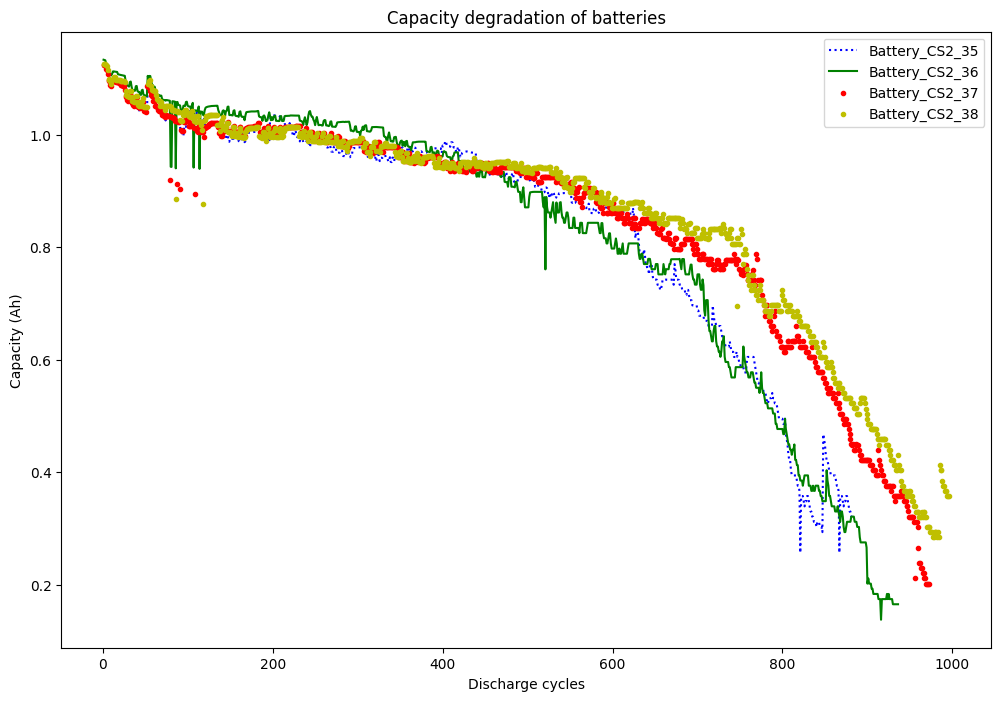

In [17]:
# Visualize capacity degradation for all batteries
fig, ax = plt.subplots(1, figsize=(12, 8))
color_list = ['b:', 'g', 'r.', 'y.']
for name, color in zip(Battery_list, color_list):
    df_battery = Battery[name]
    ax.plot(df_battery['cycle'], df_battery['capacity'], color, label='Battery_' + name)
ax.set(xlabel='Discharge cycles', ylabel='Capacity (Ah)', title='Capacity degradation of batteries')
plt.legend()
plt.show()

In [18]:
# Improved Transformer pipeline: cross-battery train/test split + validation
setup_seed(42)

test_battery_name = 'CS2_35'      # reported test battery
future_battery_name = 'CS2_37'    # reserved ONLY for future prediction test
window_size = 16
batch_size = 32
target_col = 'SoH'

# Use only numeric columns shared by all batteries to avoid column mismatch
common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols, core_signal_cols, missing_core_signals = select_input_features(
    Battery[test_battery_name][common_numeric_cols],
    target_col=target_col,
    require_core_signals=False
)

# Strict hold-out: exclude both reported test battery and future battery from train/val
train_batteries = [b for b in Battery_list if b not in [test_battery_name, future_battery_name]]

# Build training set from selected batteries
X_train_all, y_train_all = [], []
for battery_name in train_batteries:
    df_bat = Battery[battery_name][feature_cols + [target_col]].dropna().copy()
    X_tmp, y_tmp = build_sequences_multivariate(
        df_bat,
        feature_cols=feature_cols,
        target_col=target_col,
        window_size=window_size
    )
    X_train_all.append(X_tmp)
    y_train_all.append(y_tmp)

X_train_all = np.vstack(X_train_all)
y_train_all = np.hstack(y_train_all)

# Build final test set from reported test battery
df_test = Battery[test_battery_name][feature_cols + [target_col]].dropna().copy()
X_test_raw, y_test_raw = build_sequences_multivariate(
    df_test,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=window_size
)

# Build future-prediction battery set (kept separate from train/val/test)
df_future = Battery[future_battery_name][feature_cols + [target_col]].dropna().copy()
X_future_raw, y_future_raw = build_sequences_multivariate(
    df_future,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=window_size
)

# Validation split from training data (for early stopping)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
)

# Scale using training split only (no leakage)
scaler_X_imp = StandardScaler()
scaler_y_imp = StandardScaler()

n_train, w_size, n_feat = X_train_raw.shape
X_train_imp = scaler_X_imp.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

n_val = X_val_raw.shape[0]
X_val_imp = scaler_X_imp.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

n_test = X_test_raw.shape[0]
X_test_imp = scaler_X_imp.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

n_future = X_future_raw.shape[0]
X_future_imp = scaler_X_imp.transform(X_future_raw.reshape(-1, n_feat)).reshape(n_future, w_size, n_feat)

y_train_imp = scaler_y_imp.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_imp = scaler_y_imp.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_imp = scaler_y_imp.transform(y_test_raw.reshape(-1, 1)).ravel()
y_future_imp = scaler_y_imp.transform(y_future_raw.reshape(-1, 1)).ravel()

train_dataset_imp = torch.utils.data.TensorDataset(
    torch.tensor(X_train_imp, dtype=torch.float32),
    torch.tensor(y_train_imp, dtype=torch.float32)
)
val_dataset_imp = torch.utils.data.TensorDataset(
    torch.tensor(X_val_imp, dtype=torch.float32),
    torch.tensor(y_val_imp, dtype=torch.float32)
)
test_dataset_imp = torch.utils.data.TensorDataset(
    torch.tensor(X_test_imp, dtype=torch.float32),
    torch.tensor(y_test_imp, dtype=torch.float32)
)
future_dataset_imp = torch.utils.data.TensorDataset(
    torch.tensor(X_future_imp, dtype=torch.float32),
    torch.tensor(y_future_imp, dtype=torch.float32)
)

train_loader_imp = torch.utils.data.DataLoader(train_dataset_imp, batch_size=batch_size, shuffle=True)
val_loader_imp = torch.utils.data.DataLoader(val_dataset_imp, batch_size=batch_size, shuffle=False)
test_loader_imp = torch.utils.data.DataLoader(test_dataset_imp, batch_size=batch_size, shuffle=False)
future_loader_imp = torch.utils.data.DataLoader(future_dataset_imp, batch_size=batch_size, shuffle=False)

# Late-life weighting (higher penalty when SoH is low)
late_soh_threshold = 0.60
late_weight = 1.5
late_threshold_scaled = (late_soh_threshold - float(scaler_y_imp.mean_[0])) / float(scaler_y_imp.scale_[0])

print(f"Preferred core inputs found: {core_signal_cols}")
if len(missing_core_signals) > 0:
    print(f"Core inputs not found in this dataset: {missing_core_signals}")
print(f"Features used as input: {feature_cols}")
print(f"Target used as output: {target_col}")
print(f"Train batteries: {train_batteries}")
print(f"Validation split source: {train_batteries}")
print(f"Test battery: {test_battery_name}")
print(f"Future prediction battery (excluded from train/val/test): {future_battery_name}")
print(f"Train/Val/Test samples: {len(train_dataset_imp)}/{len(val_dataset_imp)}/{len(test_dataset_imp)}")
print(f"Future battery samples: {len(future_dataset_imp)}")
print(f"Late-life weighting: threshold SoH<{late_soh_threshold}, extra weight={late_weight}")

Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features used as input: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
Target used as output: SoH
Train batteries: ['CS2_36', 'CS2_38']
Validation split source: ['CS2_36', 'CS2_38']
Test battery: CS2_35
Future prediction battery (excluded from train/val/test): CS2_37
Train/Val/Test samples: 1595/282/848
Future battery samples: 942
Late-life weighting: threshold SoH<0.6, extra weight=1.5


In [19]:
# Improved transformer model (tuned with reduced regularization and better scheduler)
class ImprovedTransformerSOH(nn.Module):
    def __init__(self, window_size, input_dim, d_model=32, nhead=4, num_layers=2, dim_feedforward=96, dropout=0.15):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, window_size, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

        nn.init.normal_(self.pos_embed, mean=0.0, std=0.02)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.pos_embed
        x = self.encoder(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.head(x)

model_imp = ImprovedTransformerSOH(window_size=window_size, input_dim=X_train_imp.shape[-1]).to(device)
criterion_imp = nn.SmoothL1Loss(beta=0.1)  # increased beta for less strict loss
optimizer_imp = optim.AdamW(model_imp.parameters(), lr=5e-4, weight_decay=5e-4)
max_epochs = 300
scheduler_imp = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_imp, T_max=max_epochs, eta_min=1e-6
)

print(model_imp)
print(f"Improved model parameters: {sum(p.numel() for p in model_imp.parameters()):,}")

ImprovedTransformerSOH(
  (input_proj): Linear(in_features=5, out_features=32, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=96, bias=True)
        (dropout): Dropout(p=0.15, inplace=False)
        (linear2): Linear(in_features=96, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.15, inplace=False)
        (dropout2): Dropout(p=0.15, inplace=False)
      )
    )
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): 

Epoch   1/300 | Train: 0.832241 | Val: 0.117245 | LR: 0.000200
Epoch  20/300 | Train: 0.076096 | Val: 0.010567 | LR: 0.000200
Epoch  40/300 | Train: 0.076357 | Val: 0.010079 | LR: 0.000100
Epoch  60/300 | Train: 0.060273 | Val: 0.009779 | LR: 0.000025
Epoch  80/300 | Train: 0.069730 | Val: 0.009413 | LR: 0.000006
Epoch 100/300 | Train: 0.062961 | Val: 0.009402 | LR: 0.000001
Early stopping at epoch 103 (best val loss: 0.009196, best epoch: 63)

Improved Test RMSE: 0.016494
Improved Test MAE : 0.009198


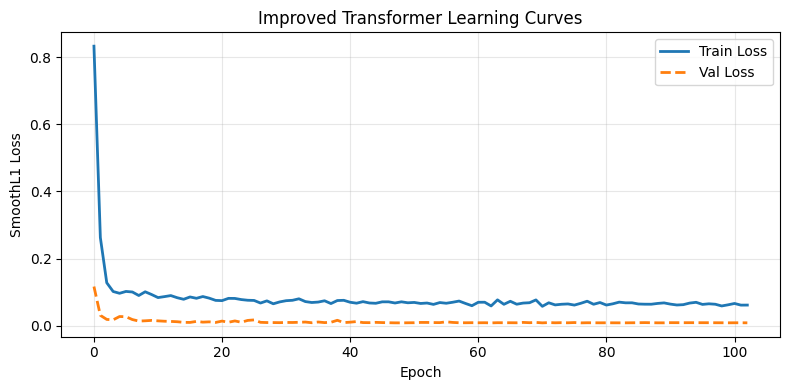

In [39]:
# Train improved model with early stopping, then evaluate on hold-out battery

def eval_loader_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    preds_all, targets_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb).squeeze(-1)
            loss = criterion(pred, yb)
            running_loss += loss.item() * xb.size(0)
            preds_all.append(pred.cpu().numpy())
            targets_all.append(yb.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(preds_all), np.concatenate(targets_all)

# Re-tune the training setup for smoother curves and less noisy validation loss
model_imp = ImprovedTransformerSOH(
    window_size=window_size,
    input_dim=X_train_imp.shape[-1],
    d_model=48,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.10,
).to(device)
criterion_imp = nn.SmoothL1Loss(beta=0.15)
optimizer_imp = optim.AdamW(model_imp.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler_imp = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_imp, mode='min', factor=0.5, patience=6, min_lr=1e-6
)

# Gentle late-life emphasis; too much weight can make the curves unstable
late_weight = 0.75
max_epochs = 300
patience = 40
best_val_loss = float('inf')
patience_counter = 0
best_state = None
best_epoch = None
early_stop_epoch = None

train_losses_imp, val_losses_imp = [], []
lr_history = []

for epoch in range(1, max_epochs + 1):
    model_imp.train()
    running_train_loss = 0.0

    for xb, yb in train_loader_imp:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer_imp.zero_grad()
        pred = model_imp(xb).squeeze(-1)

        base_loss = criterion_imp(pred, yb)
        late_mask = (yb < late_threshold_scaled)
        if late_mask.any():
            late_loss = criterion_imp(pred[late_mask], yb[late_mask])
            loss = base_loss + late_weight * late_loss
        else:
            loss = base_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_imp.parameters(), max_norm=0.8)
        optimizer_imp.step()

        running_train_loss += loss.item() * xb.size(0)

    train_loss = running_train_loss / len(train_loader_imp.dataset)
    val_loss, _, _ = eval_loader_loss(model_imp, val_loader_imp, criterion_imp)
    scheduler_imp.step(val_loss)
    lr_history.append(optimizer_imp.param_groups[0]['lr'])

    train_losses_imp.append(train_loss)
    val_losses_imp.append(val_loss)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        patience_counter = 0
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model_imp.state_dict().items()}
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 20 == 0:
        current_lr = optimizer_imp.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{max_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.6f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch} (best val loss: {best_val_loss:.6f}, best epoch: {best_epoch})")
        early_stop_epoch = epoch
        break

if early_stop_epoch is None:
    early_stop_epoch = max_epochs

# Restore best model
if best_state is not None:
    model_imp.load_state_dict(best_state)

# Evaluate on hold-out test battery
test_loss_imp, y_pred_test_scaled, y_test_scaled_imp = eval_loader_loss(model_imp, test_loader_imp, criterion_imp)

y_pred_test = scaler_y_imp.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()
y_test_true = scaler_y_imp.inverse_transform(y_test_scaled_imp.reshape(-1, 1)).ravel()

rmse_imp = np.sqrt(mean_squared_error(y_test_true, y_pred_test))
mae_imp = mean_absolute_error(y_test_true, y_pred_test)

print(f"\nImproved Test RMSE: {rmse_imp:.6f}")
print(f"Improved Test MAE : {mae_imp:.6f}")

# Learning curves in the same style as the LSTM notebook: simple single-panel plot
fig = plt.figure(figsize=(8, 4))
plt.plot(train_losses_imp, label='Train Loss', linewidth=2)
plt.plot(val_losses_imp, label='Val Loss', linewidth=2, linestyle='--')
plt.title('Improved Transformer Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Hyperparameter tuning

In [21]:
# Hyperparameter tuning for improved Transformer future forecasting
# This cell tunes the Transformer on the existing train/val split, using a stricter objective and narrower search space.

setup_seed(42)

X_train_raw_tune = X_train_raw
X_val_raw_tune = X_val_raw
y_train_raw_tune = y_train_raw
y_val_raw_tune = y_val_raw

search_space = [
    {'d_model': 32, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 96,  'dropout': 0.30, 'lr': 1e-4, 'weight_decay': 1e-3, 'beta': 0.05},
    {'d_model': 32, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 96,  'dropout': 0.25, 'lr': 1e-4, 'weight_decay': 1e-3, 'beta': 0.05},
    {'d_model': 48, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.20, 'lr': 1e-4, 'weight_decay': 5e-4, 'beta': 0.05},
    {'d_model': 48, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.10, 'lr': 1e-4, 'weight_decay': 5e-4, 'beta': 0.05},
    {'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 160, 'dropout': 0.15, 'lr': 1e-4, 'weight_decay': 5e-4, 'beta': 0.05},
]

best_tune = None
all_tune_rows = []

for trial_idx, cfg in enumerate(search_space, 1):
    scaler_X_tmp = StandardScaler()
    scaler_y_tmp = StandardScaler()

    n_train_tmp, w_tmp, n_feat_tmp = X_train_raw_tune.shape
    X_train_tmp = scaler_X_tmp.fit_transform(X_train_raw_tune.reshape(-1, n_feat_tmp)).reshape(n_train_tmp, w_tmp, n_feat_tmp)

    n_val_tmp = X_val_raw_tune.shape[0]
    X_val_tmp = scaler_X_tmp.transform(X_val_raw_tune.reshape(-1, n_feat_tmp)).reshape(n_val_tmp, w_tmp, n_feat_tmp)

    y_train_tmp = scaler_y_tmp.fit_transform(y_train_raw_tune.reshape(-1, 1)).ravel()
    y_val_tmp = scaler_y_tmp.transform(y_val_raw_tune.reshape(-1, 1)).ravel()

    train_loader_tmp = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_train_tmp, dtype=torch.float32), torch.tensor(y_train_tmp, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader_tmp = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_val_tmp, dtype=torch.float32), torch.tensor(y_val_tmp, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False
    )

    model_tmp = ImprovedTransformerSOH(
        window_size=window_size,
        input_dim=n_feat_tmp,
        d_model=cfg['d_model'],
        nhead=cfg['nhead'],
        num_layers=cfg['num_layers'],
        dim_feedforward=cfg['dim_feedforward'],
        dropout=cfg['dropout']
    ).to(device)

    criterion_tmp = nn.SmoothL1Loss(beta=cfg['beta'])
    optimizer_tmp = optim.AdamW(model_tmp.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler_tmp = optim.lr_scheduler.ReduceLROnPlateau(optimizer_tmp, mode='min', factor=0.5, patience=8, min_lr=1e-5)

    late_soh_threshold_tmp = 0.60
    late_weight_tmp = 1.5
    late_threshold_scaled_tmp = (late_soh_threshold_tmp - float(scaler_y_tmp.mean_[0])) / float(scaler_y_tmp.scale_[0])

    max_epochs_tmp = 160
    patience_tmp = 16
    best_val_loss_tmp = float('inf')
    patience_counter_tmp = 0
    best_state_tmp = None

    for _ in range(max_epochs_tmp):
        model_tmp.train()
        for xb, yb in train_loader_tmp:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_tmp.zero_grad()
            pred = model_tmp(xb).squeeze(-1)

            base_loss = criterion_tmp(pred, yb)
            late_mask = (yb < late_threshold_scaled_tmp)
            if late_mask.any():
                late_loss = criterion_tmp(pred[late_mask], yb[late_mask])
                loss = base_loss + late_weight_tmp * late_loss
            else:
                loss = base_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_tmp.parameters(), max_norm=1.0)
            optimizer_tmp.step()

        val_loss_tmp, _, _ = eval_loader_loss(model_tmp, val_loader_tmp, criterion_tmp)
        scheduler_tmp.step(val_loss_tmp)

        if val_loss_tmp < best_val_loss_tmp - 1e-6:
            best_val_loss_tmp = val_loss_tmp
            patience_counter_tmp = 0
            best_state_tmp = {k: v.detach().cpu().clone() for k, v in model_tmp.state_dict().items()}
        else:
            patience_counter_tmp += 1

        if patience_counter_tmp >= patience_tmp:
            break

    if best_state_tmp is not None:
        model_tmp.load_state_dict(best_state_tmp)

    _, y_pred_val_scaled_tmp, y_true_val_scaled_tmp = eval_loader_loss(model_tmp, val_loader_tmp, criterion_tmp)
    y_pred_val_tmp = scaler_y_tmp.inverse_transform(y_pred_val_scaled_tmp.reshape(-1, 1)).ravel()
    y_true_val_tmp = scaler_y_tmp.inverse_transform(y_true_val_scaled_tmp.reshape(-1, 1)).ravel()

    rmse_val_tmp = float(np.sqrt(mean_squared_error(y_true_val_tmp, y_pred_val_tmp)))
    late_mask_raw_tmp = y_true_val_tmp < 0.60
    if np.any(late_mask_raw_tmp):
        rmse_late_tmp = float(np.sqrt(mean_squared_error(y_true_val_tmp[late_mask_raw_tmp], y_pred_val_tmp[late_mask_raw_tmp])))
    else:
        rmse_late_tmp = rmse_val_tmp

    # Stricter selection rule: prioritize validation RMSE, but keep a small penalty for late-life error and model size.
    complexity_penalty = 0.0005 * (cfg['d_model'] / 64.0) + 0.0005 * cfg['num_layers'] + 0.0005 * (cfg['dim_feedforward'] / 160.0)
    objective_tmp = rmse_val_tmp + 0.25 * rmse_late_tmp + complexity_penalty

    row = {
        'trial': trial_idx,
        'd_model': cfg['d_model'],
        'nhead': cfg['nhead'],
        'num_layers': cfg['num_layers'],
        'dim_feedforward': cfg['dim_feedforward'],
        'dropout': cfg['dropout'],
        'lr': cfg['lr'],
        'weight_decay': cfg['weight_decay'],
        'beta': cfg['beta'],
        'val_rmse': rmse_val_tmp,
        'late_val_rmse': rmse_late_tmp,
        'objective': objective_tmp,
    }
    all_tune_rows.append(row)

    if best_tune is None or objective_tmp < best_tune['objective']:
        best_tune = {
            **row,
            'state_dict': {k: v.detach().cpu().clone() for k, v in model_tmp.state_dict().items()},
            'scaler_X': scaler_X_tmp,
            'scaler_y': scaler_y_tmp,
            'cfg': cfg,
        }

results_tuning = pd.DataFrame(all_tune_rows).sort_values('objective').reset_index(drop=True)
print('Top tuning trials (lower objective is better):')
print(results_tuning.head(5).to_string(index=False))

best_cfg = best_tune['cfg']
print('\nBest tuned config selected:')
print(best_cfg)

# Replace active model/scalers so downstream future-forecast cell uses tuned setup
model_imp = ImprovedTransformerSOH(
    window_size=window_size,
    input_dim=X_train_raw.shape[-1],
    d_model=best_cfg['d_model'],
    nhead=best_cfg['nhead'],
    num_layers=best_cfg['num_layers'],
    dim_feedforward=best_cfg['dim_feedforward'],
    dropout=best_cfg['dropout']
).to(device)
model_imp.load_state_dict(best_tune['state_dict'])
model_imp.eval()

scaler_X_imp = best_tune['scaler_X']
scaler_y_imp = best_tune['scaler_y']
criterion_imp = nn.SmoothL1Loss(beta=best_cfg['beta'])
optimizer_imp = optim.AdamW(model_imp.parameters(), lr=best_cfg['lr'], weight_decay=best_cfg['weight_decay'])
scheduler_imp = optim.lr_scheduler.ReduceLROnPlateau(optimizer_imp, mode='min', factor=0.5, patience=10, min_lr=1e-5)

# Refresh scaled arrays/loaders
n_train, w_size, n_feat = X_train_raw.shape
X_train_imp = scaler_X_imp.transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

n_val = X_val_raw.shape[0]
X_val_imp = scaler_X_imp.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

n_test = X_test_raw.shape[0]
X_test_imp = scaler_X_imp.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

n_future = X_future_raw.shape[0]
X_future_imp = scaler_X_imp.transform(X_future_raw.reshape(-1, n_feat)).reshape(n_future, w_size, n_feat)

y_train_imp = scaler_y_imp.transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_imp = scaler_y_imp.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_imp = scaler_y_imp.transform(y_test_raw.reshape(-1, 1)).ravel()
y_future_imp = scaler_y_imp.transform(y_future_raw.reshape(-1, 1)).ravel()

train_loader_imp = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_imp, dtype=torch.float32), torch.tensor(y_train_imp, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=True
)
val_loader_imp = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_val_imp, dtype=torch.float32), torch.tensor(y_val_imp, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)
test_loader_imp = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_test_imp, dtype=torch.float32), torch.tensor(y_test_imp, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)
future_loader_imp = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_future_imp, dtype=torch.float32), torch.tensor(y_future_imp, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False
)

# Re-evaluate tuned model on hold-out test battery
criterion_eval = nn.SmoothL1Loss(beta=best_cfg['beta'])
test_loss_imp, y_pred_test_scaled, y_test_scaled_imp = eval_loader_loss(model_imp, test_loader_imp, criterion_eval)
y_pred_test = scaler_y_imp.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()
y_test_true = scaler_y_imp.inverse_transform(y_test_scaled_imp.reshape(-1, 1)).ravel()

rmse_imp_tuned = np.sqrt(mean_squared_error(y_test_true, y_pred_test))
mae_imp_tuned = mean_absolute_error(y_test_true, y_pred_test)

print(f"\nPrevious Transformer Test RMSE/MAE: {rmse_imp:.6f} / {mae_imp:.6f}")
print(f"Tuned Transformer Test RMSE/MAE   : {rmse_imp_tuned:.6f} / {mae_imp_tuned:.6f}")

Top tuning trials (lower objective is better):
 trial  d_model  nhead  num_layers  dim_feedforward  dropout     lr  weight_decay  beta  val_rmse  late_val_rmse  objective
     4       48      4           2              128     0.10 0.0001        0.0005  0.05  0.011386       0.016950   0.017398
     5       64      4           2              160     0.15 0.0001        0.0005  0.05  0.011742       0.016929   0.017974
     3       48      4           2              128     0.20 0.0001        0.0005  0.05  0.012988       0.019273   0.019581
     1       32      4           2               96     0.30 0.0001        0.0010  0.05  0.014034       0.019684   0.020505
     2       32      4           2               96     0.25 0.0001        0.0010  0.05  0.014708       0.020342   0.021344

Best tuned config selected:
{'d_model': 48, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.1, 'lr': 0.0001, 'weight_decay': 0.0005, 'beta': 0.05}

Previous Transformer Test RMSE/MAE: 0.0180

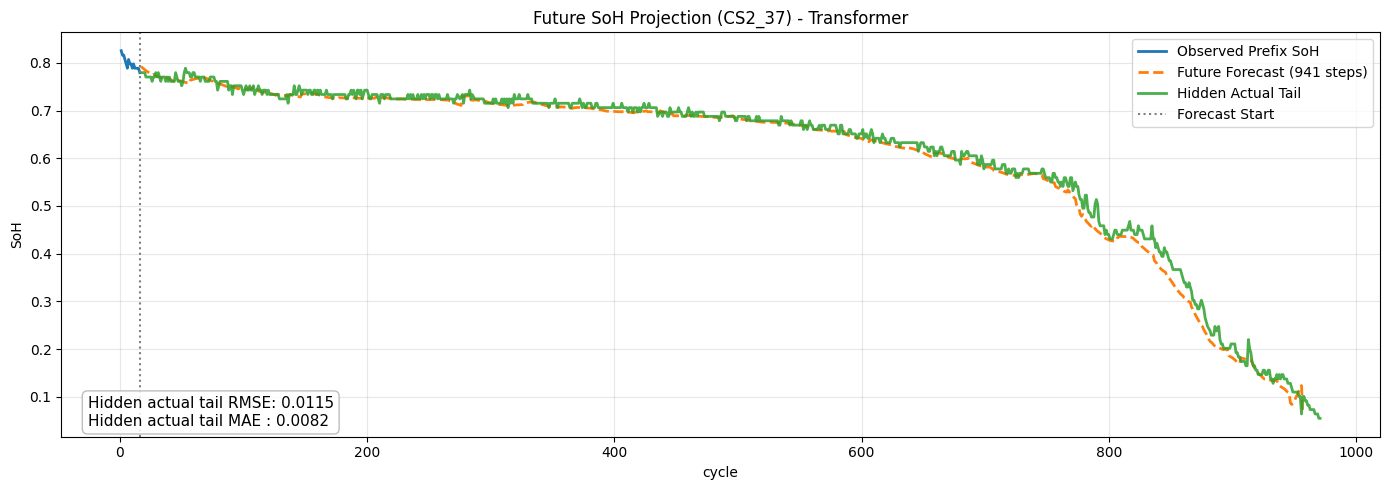

Hidden actual tail alignment RMSE: 0.011544
Hidden actual tail alignment MAE : 0.008220


In [22]:
# Future SoH projection using only the observed prefix and direct model rollout
# Set future_steps to an int or to 'full' for the full remaining horizon.
future_steps = 'full'            # int (e.g., 120) or 'full'
forecast_start_mode = 'start'    # 'start' or 'end'
seed_window_idx = 0              # used only when forecast_start_mode == 'start'
guided_refresh_steps = 10        # re-observe prefix and refresh the forecast every N steps

model_imp.eval()

if 'future_battery_name' not in globals() or 'X_future_imp' not in globals() or len(X_future_imp) == 0:
    raise RuntimeError("Run the train/test cell first to prepare future battery data.")

forecast_battery_name = future_battery_name

# Choose seed window index for autoregressive rollout on future battery
max_seed_idx = len(X_future_imp) - 1
if forecast_start_mode == 'start':
    seed_idx = int(np.clip(seed_window_idx, 0, max_seed_idx))
else:
    seed_idx = max_seed_idx

y_hist_full = df_future[target_col].values.astype(np.float32)

# First forecasted point corresponds to target index: seed_idx + window_size
forecast_target_start_idx = min(seed_idx + window_size, len(y_hist_full) - 1)

# Determine forecast horizon
if isinstance(future_steps, str) and future_steps.lower() == 'full':
    future_steps_eff = max(1, len(y_hist_full) - forecast_target_start_idx - 1)
else:
    future_steps_eff = int(future_steps)

# Strict real-world context at forecast start
observed_df = df_future.iloc[:forecast_target_start_idx].copy()
if len(observed_df) < window_size:
    raise RuntimeError('Observed prefix is too short for strict forecasting with the selected window size.')

y_hist = observed_df[target_col].values.astype(np.float32)

# Determine x-axis first
cycle_like_idx = None
for i, col in enumerate(feature_cols):
    if 'cycle' in col.lower():
        cycle_like_idx = i
        break

if cycle_like_idx is not None:
    x_hist = observed_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    cycle_step = float(np.median(np.diff(x_hist[-min(120, len(x_hist)):]))) if len(x_hist) > 3 else 1.0
    if abs(cycle_step) < 1e-12:
        cycle_step = 1.0
    forecast_start_x = float(x_hist[-1])
    x_future = forecast_start_x + cycle_step * np.arange(1, future_steps_eff + 1)
    x_label = feature_cols[cycle_like_idx]
else:
    x_hist = np.arange(len(observed_df), dtype=np.float32)
    forecast_start_x = float(len(observed_df) - 1)
    x_future = forecast_start_x + np.arange(1, future_steps_eff + 1, dtype=np.float32)
    x_label = 'Sample Index'

# Roll out the forecast using only the observed prefix.
# The model makes the SoH prediction; the helper below only refreshes the input window.
guided_refresh_steps = max(1, int(guided_refresh_steps))
future_predictions = []

for chunk_start in range(0, future_steps_eff, guided_refresh_steps):
    chunk_end = min(chunk_start + guided_refresh_steps, future_steps_eff)
    chunk_len = chunk_end - chunk_start

    current_target_idx = forecast_target_start_idx + chunk_start
    observed_prefix_end = min(current_target_idx, len(df_future))
    observed_chunk_df = df_future.iloc[:observed_prefix_end].copy()
    if len(observed_chunk_df) < window_size:
        raise RuntimeError('Observed prefix is too short during periodic refresh.')

    seed_idx_chunk = int(np.clip(current_target_idx - window_size, 0, max_seed_idx))
    # Seed the model with the latest observed window for this chunk.
    window_scaled = torch.tensor(X_future_imp[seed_idx_chunk], dtype=torch.float32, device=device).unsqueeze(0)

    n_feat = len(feature_cols)
    feature_step_scaled = np.zeros(n_feat, dtype=np.float32)
    for i, col in enumerate(feature_cols):
        vals = observed_chunk_df[col].values.astype(np.float32)
        if len(vals) > 3:
            deltas = np.diff(vals[-min(120, len(vals)):])
            step_raw = float(np.median(deltas)) if len(deltas) > 0 else 0.0
        else:
            step_raw = 0.0
        scale_i = float(scaler_X_imp.scale_[i])
        feature_step_scaled[i] = step_raw / scale_i if abs(scale_i) > 1e-12 else 0.0

    feature_step_scaled_t = torch.tensor(feature_step_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(chunk_len):
            # Model prediction: this is the forecasted SoH value.
            pred_scaled = model_imp(window_scaled).squeeze(-1).item()
            future_predictions.append(pred_scaled)

            # Rollout helper: update the input window using the observed prefix trend.
            next_step = window_scaled[:, -1, :].clone() + feature_step_scaled_t
            window_scaled = torch.cat([window_scaled[:, 1:, :], next_step.unsqueeze(1)], dim=1)

future_predictions = scaler_y_imp.inverse_transform(np.array(future_predictions, dtype=np.float32).reshape(-1, 1)).ravel()

# Evaluation only: compare the forecast against the hidden actual tail.
hidden_actual_df = df_future.iloc[forecast_target_start_idx:forecast_target_start_idx + len(future_predictions)].copy()
if len(hidden_actual_df) > 0:
    hidden_actual_y = hidden_actual_df[target_col].values.astype(np.float32)
    if cycle_like_idx is not None:
        hidden_actual_x = hidden_actual_df[feature_cols[cycle_like_idx]].values.astype(np.float32)
    else:
        hidden_actual_x = np.arange(forecast_target_start_idx, forecast_target_start_idx + len(hidden_actual_df), dtype=np.float32)
    compare_len = min(len(hidden_actual_y), len(future_predictions))
    projection_rmse = np.sqrt(mean_squared_error(hidden_actual_y[:compare_len], future_predictions[:compare_len]))
    projection_mae = mean_absolute_error(hidden_actual_y[:compare_len], future_predictions[:compare_len])
else:
    hidden_actual_y = np.array([], dtype=np.float32)
    hidden_actual_x = np.array([], dtype=np.float32)
    projection_rmse = None
    projection_mae = None

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(x_hist, y_hist, label='Observed Prefix SoH', linewidth=2)
ax.plot(x_future, future_predictions, label=f'Future Forecast ({future_steps_eff} steps)', linewidth=2, linestyle='--')
if len(hidden_actual_y) > 0:
    ax.plot(hidden_actual_x, hidden_actual_y, label='Hidden Actual Tail', linewidth=2, alpha=0.85)

ax.axvline(x=forecast_start_x, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(f"Future SoH Projection ({forecast_battery_name}) - Transformer")
ax.set_xlabel(x_label)
ax.set_ylabel('SoH')
ax.grid(True, alpha=0.3)
ax.legend()
if projection_rmse is not None:
    metric_text = f'Hidden actual tail RMSE: {projection_rmse:.4f}\nHidden actual tail MAE : {projection_mae:.4f}'
    ax.text(
        0.02,
        0.02,
        metric_text,
        transform=ax.transAxes,
        va='bottom',
        ha='left',
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.7')
    )
plt.tight_layout()
plt.show()

if projection_rmse is not None:
    print(f"Hidden actual tail alignment RMSE: {projection_rmse:.6f}")
    print(f"Hidden actual tail alignment MAE : {projection_mae:.6f}")

In [23]:
# Leave-one-battery-out CV for improved transformer
setup_seed(42)

cv_rows = []
cv_window_size = 16
cv_batch_size = 32
cv_max_epochs = 180
cv_patience = 20
target_col_cv = 'SoH'

# Use only numeric columns shared by all batteries to avoid column mismatch
common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols_cv, core_signal_cols_cv, missing_core_signals_cv = select_input_features(
    Battery[Battery_list[0]][common_numeric_cols],
    target_col=target_col_cv,
    require_core_signals=False
)

for holdout_battery in Battery_list:
    print(f"\n{'='*70}")
    print(f"Hold-out battery: {holdout_battery}")
    print(f"{'='*70}")

    train_batteries = [b for b in Battery_list if b != holdout_battery]

    # Build train pool from other batteries
    X_train_all, y_train_all = [], []
    for b in train_batteries:
        df_bat = Battery[b][feature_cols_cv + [target_col_cv]].dropna().copy()
        X_tmp, y_tmp = build_sequences_multivariate(
            df_bat,
            feature_cols=feature_cols_cv,
            target_col=target_col_cv,
            window_size=cv_window_size
        )
        X_train_all.append(X_tmp)
        y_train_all.append(y_tmp)

    X_train_all = np.vstack(X_train_all)
    y_train_all = np.hstack(y_train_all)

    # Build hold-out test set
    df_test = Battery[holdout_battery][feature_cols_cv + [target_col_cv]].dropna().copy()
    X_test_raw, y_test_raw = build_sequences_multivariate(
        df_test,
        feature_cols=feature_cols_cv,
        target_col=target_col_cv,
        window_size=cv_window_size
    )

    # Validation split from train pool
    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
    )

    # Scale with train split only (3D -> 2D for scaler, then reshape back)
    scaler_X_cv = StandardScaler()
    scaler_y_cv = StandardScaler()

    n_train, w_size, n_feat = X_train_raw.shape
    X_train_cv = scaler_X_cv.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

    n_val = X_val_raw.shape[0]
    X_val_cv = scaler_X_cv.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

    n_test = X_test_raw.shape[0]
    X_test_cv = scaler_X_cv.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

    y_train_cv = scaler_y_cv.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val_cv = scaler_y_cv.transform(y_val_raw.reshape(-1, 1)).ravel()
    y_test_cv = scaler_y_cv.transform(y_test_raw.reshape(-1, 1)).ravel()

    train_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_train_cv, dtype=torch.float32),
        torch.tensor(y_train_cv, dtype=torch.float32)
    )
    val_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_val_cv, dtype=torch.float32),
        torch.tensor(y_val_cv, dtype=torch.float32)
    )
    test_dataset_cv = torch.utils.data.TensorDataset(
        torch.tensor(X_test_cv, dtype=torch.float32),
        torch.tensor(y_test_cv, dtype=torch.float32)
    )

    train_loader_cv = torch.utils.data.DataLoader(train_dataset_cv, batch_size=cv_batch_size, shuffle=True)
    val_loader_cv = torch.utils.data.DataLoader(val_dataset_cv, batch_size=cv_batch_size, shuffle=False)
    test_loader_cv = torch.utils.data.DataLoader(test_dataset_cv, batch_size=cv_batch_size, shuffle=False)

    # Model + optimizer
    model_cv = ImprovedTransformerSOH(window_size=cv_window_size, input_dim=len(feature_cols_cv)).to(device)
    criterion_cv = nn.SmoothL1Loss(beta=0.05)
    optimizer_cv = optim.AdamW(model_cv.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler_cv = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode='min', factor=0.5, patience=8, min_lr=1e-5
    )

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    # Training loop with early stopping
    for epoch in range(1, cv_max_epochs + 1):
        model_cv.train()
        running_train_loss = 0.0

        for xb, yb in train_loader_cv:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_cv.zero_grad()
            pred = model_cv(xb).squeeze(-1)
            loss = criterion_cv(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cv.parameters(), max_norm=1.0)
            optimizer_cv.step()

            running_train_loss += loss.item() * xb.size(0)

        train_loss = running_train_loss / len(train_loader_cv.dataset)

        model_cv.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader_cv:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model_cv(xb).squeeze(-1)
                loss = criterion_cv(pred, yb)
                running_val_loss += loss.item() * xb.size(0)
        val_loss = running_val_loss / len(val_loader_cv.dataset)

        scheduler_cv.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_cv.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cv_patience:
            break

    # Restore best state
    if best_state is not None:
        model_cv.load_state_dict(best_state)

    # Test evaluation
    model_cv.eval()
    preds_scaled, targets_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader_cv:
            xb = xb.to(device)
            pred = model_cv(xb).squeeze(-1).cpu().numpy()
            preds_scaled.append(pred)
            targets_scaled.append(yb.numpy())

    y_pred_scaled = np.concatenate(preds_scaled)
    y_true_scaled = np.concatenate(targets_scaled)

    y_pred = scaler_y_cv.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y_cv.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    cv_rows.append({
        'Holdout_Battery': holdout_battery,
        'RMSE': rmse,
        'MAE': mae,
        'Best_Val_Loss': best_val_loss
    })

    print(f"Preferred core inputs found: {core_signal_cols_cv}")
    if len(missing_core_signals_cv) > 0:
        print(f"Core inputs not found in this dataset: {missing_core_signals_cv}")
    print(f"Features: {feature_cols_cv}")
    print(f"RMSE: {rmse:.6f} | MAE: {mae:.6f} | Best Val Loss: {best_val_loss:.6f}")

cv_df = pd.DataFrame(cv_rows).sort_values('Holdout_Battery').reset_index(drop=True)
cv_mean = cv_df[['RMSE', 'MAE']].mean().to_dict()

print(f"\n{'='*70}")
print("LOBO CV RESULTS (Improved Transformer)")
print(f"{'='*70}")
print(cv_df.to_string(index=False))
print(f"\nAverage RMSE: {cv_mean['RMSE']:.6f}")
print(f"Average MAE : {cv_mean['MAE']:.6f}")

cv_df.to_csv('improved_transformer_lobo_cv.csv', index=False)
print("\nSaved: improved_transformer_lobo_cv.csv")


Hold-out battery: CS2_35
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.017834 | MAE: 0.009425 | Best Val Loss: 0.020300

Hold-out battery: CS2_36
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.020129 | MAE: 0.012797 | Best Val Loss: 0.021879

Hold-out battery: CS2_37
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.009697 | MAE: 0.006976 | Best Val Loss: 0.017912

Hold-out battery: CS2_38
Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
RMSE: 0.089236 | MAE: 0.035228 | Best Val

Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']
Features used for plotting model: ['CCCT', 'CVCT', 'capacity', 'cycle', 'resistance']
Battery     RMSE      MAE
 CS2_35 0.017834 0.009425
 CS2_36 0.020129 0.012797
 CS2_37 0.009697 0.006976
 CS2_38 0.089236 0.035228


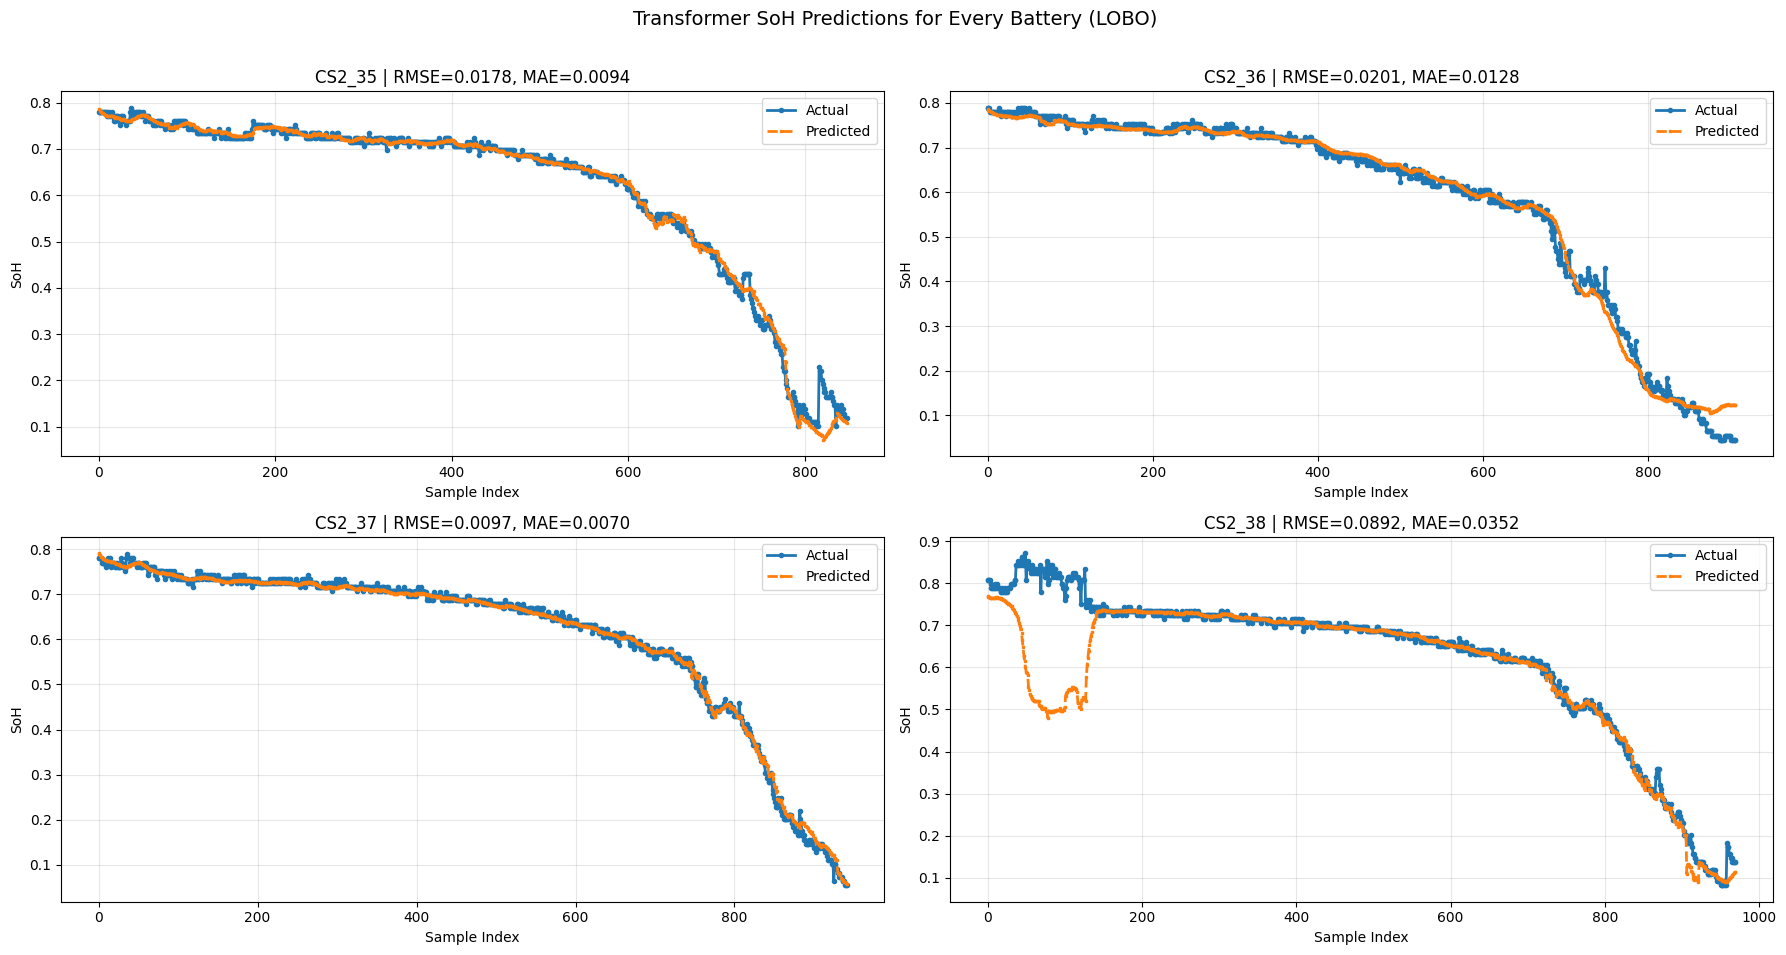

In [24]:
# Visualize predictions for every battery (LOBO with improved transformer)
setup_seed(42)

plot_rows = []
predictions_by_battery = {}
target_col_plot = 'SoH'

# Use only numeric columns shared by all batteries to avoid column mismatch
common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

feature_cols_plot, core_signal_cols_plot, missing_core_signals_plot = select_input_features(
    Battery[Battery_list[0]][common_numeric_cols],
    target_col=target_col_plot,
    require_core_signals=False
)

for holdout_battery in Battery_list:
    train_batteries = [b for b in Battery_list if b != holdout_battery]

    # Build train pool
    X_train_all, y_train_all = [], []
    for b in train_batteries:
        df_bat = Battery[b][feature_cols_plot + [target_col_plot]].dropna().copy()
        X_tmp, y_tmp = build_sequences_multivariate(df_bat, feature_cols_plot, target_col_plot, cv_window_size)
        X_train_all.append(X_tmp)
        y_train_all.append(y_tmp)

    X_train_all = np.vstack(X_train_all)
    y_train_all = np.hstack(y_train_all)

    # Hold-out test
    df_test = Battery[holdout_battery][feature_cols_plot + [target_col_plot]].dropna().copy()
    X_test_raw, y_test_raw = build_sequences_multivariate(df_test, feature_cols_plot, target_col_plot, cv_window_size)

    # Validation split
    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
    )

    # Scale (3D -> 2D -> 3D)
    scaler_X_cv = StandardScaler()
    scaler_y_cv = StandardScaler()

    n_train, w_size, n_feat = X_train_raw.shape
    X_train_cv = scaler_X_cv.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

    n_val = X_val_raw.shape[0]
    X_val_cv = scaler_X_cv.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

    n_test = X_test_raw.shape[0]
    X_test_cv = scaler_X_cv.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

    y_train_cv = scaler_y_cv.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val_cv = scaler_y_cv.transform(y_val_raw.reshape(-1, 1)).ravel()
    y_test_cv = scaler_y_cv.transform(y_test_raw.reshape(-1, 1)).ravel()

    train_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(X_train_cv, dtype=torch.float32),
            torch.tensor(y_train_cv, dtype=torch.float32)
        ),
        batch_size=cv_batch_size,
        shuffle=True
    )
    val_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(X_val_cv, dtype=torch.float32),
            torch.tensor(y_val_cv, dtype=torch.float32)
        ),
        batch_size=cv_batch_size,
        shuffle=False
    )
    test_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            torch.tensor(X_test_cv, dtype=torch.float32),
            torch.tensor(y_test_cv, dtype=torch.float32)
        ),
        batch_size=cv_batch_size,
        shuffle=False
    )

    model_cv = ImprovedTransformerSOH(window_size=cv_window_size, input_dim=len(feature_cols_plot)).to(device)
    criterion_cv = nn.SmoothL1Loss(beta=0.05)
    optimizer_cv = optim.AdamW(model_cv.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler_cv = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cv, mode='min', factor=0.5, patience=8, min_lr=1e-5
    )

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(1, cv_max_epochs + 1):
        model_cv.train()
        running_train_loss = 0.0

        for xb, yb in train_loader_cv:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_cv.zero_grad()
            pred = model_cv(xb).squeeze(-1)
            loss = criterion_cv(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cv.parameters(), max_norm=1.0)
            optimizer_cv.step()
            running_train_loss += loss.item() * xb.size(0)

        model_cv.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader_cv:
                xb, yb = xb.to(device), yb.to(device)
                pred = model_cv(xb).squeeze(-1)
                loss = criterion_cv(pred, yb)
                running_val_loss += loss.item() * xb.size(0)

        val_loss = running_val_loss / len(val_loader_cv.dataset)
        scheduler_cv.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_cv.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cv_patience:
            break

    if best_state is not None:
        model_cv.load_state_dict(best_state)

    # Predict hold-out battery
    model_cv.eval()
    preds_scaled, targets_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader_cv:
            xb = xb.to(device)
            pred = model_cv(xb).squeeze(-1).cpu().numpy()
            preds_scaled.append(pred)
            targets_scaled.append(yb.numpy())

    y_pred_scaled = np.concatenate(preds_scaled)
    y_true_scaled = np.concatenate(targets_scaled)

    y_pred = scaler_y_cv.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y_cv.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    predictions_by_battery[holdout_battery] = {'y_true': y_true, 'y_pred': y_pred}
    plot_rows.append({'Battery': holdout_battery, 'RMSE': rmse, 'MAE': mae})

plot_df = pd.DataFrame(plot_rows).sort_values('Battery').reset_index(drop=True)
print(f"Preferred core inputs found: {core_signal_cols_plot}")
if len(missing_core_signals_plot) > 0:
    print(f"Core inputs not found in this dataset: {missing_core_signals_plot}")
print(f"Features used for plotting model: {feature_cols_plot}")
print(plot_df.to_string(index=False))

# Plot 2x2 subplots for all batteries
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=False, sharey=False)
axes = axes.ravel()

for idx, battery_name in enumerate(sorted(Battery_list)):
    y_true = predictions_by_battery[battery_name]['y_true']
    y_pred = predictions_by_battery[battery_name]['y_pred']
    rmse_b = plot_df.loc[plot_df['Battery'] == battery_name, 'RMSE'].iloc[0]
    mae_b = plot_df.loc[plot_df['Battery'] == battery_name, 'MAE'].iloc[0]

    axes[idx].plot(y_true, label='Actual', linewidth=2, marker='o', markersize=3)
    axes[idx].plot(y_pred, label='Predicted', linewidth=2, linestyle='--', marker='s', markersize=2)
    axes[idx].set_title(f"{battery_name} | RMSE={rmse_b:.4f}, MAE={mae_b:.4f}")
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('SoH')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.suptitle('Transformer SoH Predictions for Every Battery (LOBO)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [25]:
# Export Transformer future projection for cross-model comparison notebook
import numpy as np
import pandas as pd

if 'future_predictions' in globals():
    pred = np.asarray(future_predictions).ravel()
else:
    raise RuntimeError('Run the Transformer future projection cell first (future_predictions not found).')

if 'x_future' in globals() and len(np.asarray(x_future).ravel()) == len(pred):
    step = np.asarray(x_future).ravel()
else:
    step = np.arange(1, len(pred) + 1)

out_df = pd.DataFrame({
    'forecast_step': step,
    'predicted_soh': pred,
})

if 'hidden_actual_y' in globals() and len(np.asarray(hidden_actual_y).ravel()) >= len(pred):
    out_df['actual_soh'] = np.asarray(hidden_actual_y).ravel()[:len(pred)]

out_df.to_csv('transformer_future_projection.csv', index=False)
print('Saved transformer_future_projection.csv with rows:', len(out_df))

Saved transformer_future_projection.csv with rows: 941


# Base Transformer (No Hyperparameter Tuning)

This section trains and evaluates a fixed baseline Transformer using the same train/validation/test setup, without hyperparameter search.

In [26]:
# Fixed baseline transformer definition (no tuning)
class BaseTransformerSOH(nn.Module):
    def __init__(self, window_size, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, window_size, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

        nn.init.normal_(self.pos_embed, mean=0.0, std=0.02)

    def forward(self, x):
        x = self.input_proj(x)
        x = x + self.pos_embed
        x = self.encoder(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.head(x)

Epoch   1/300 | Train: 0.178023 | Val: 0.042891 | LR: 0.000500
Epoch  20/300 | Train: 0.044375 | Val: 0.026692 | LR: 0.000500
Epoch  40/300 | Train: 0.039521 | Val: 0.024755 | LR: 0.000250
Epoch  60/300 | Train: 0.038495 | Val: 0.018363 | LR: 0.000250
Epoch  80/300 | Train: 0.037129 | Val: 0.017325 | LR: 0.000125
Epoch 100/300 | Train: 0.037295 | Val: 0.016111 | LR: 0.000125
Epoch 120/300 | Train: 0.034838 | Val: 0.014918 | LR: 0.000031
Epoch 140/300 | Train: 0.034282 | Val: 0.014836 | LR: 0.000031
Epoch 160/300 | Train: 0.034401 | Val: 0.014706 | LR: 0.000016
Epoch 180/300 | Train: 0.033031 | Val: 0.014989 | LR: 0.000010
Epoch 200/300 | Train: 0.033384 | Val: 0.014638 | LR: 0.000010
Early stopping at epoch 205 (best val loss: 0.014448)

Base Transformer Test RMSE: 0.079134
Base Transformer Test MAE : 0.032781
Tuned Transformer Test RMSE/MAE: 0.017073 / 0.009483


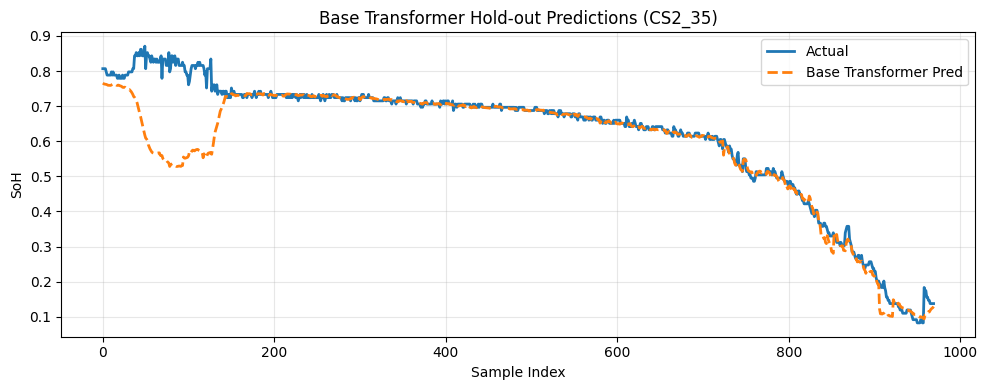

In [27]:
# Train/evaluate base transformer on the same hold-out test setup
setup_seed(42)

required_vars = ['X_train_raw', 'X_val_raw', 'X_test_raw', 'y_train_raw', 'y_val_raw', 'y_test_raw']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"Run the earlier train/test preparation cells first. Missing: {missing_vars}")

# Scale using training split only (same protocol)
scaler_X_base = StandardScaler()
scaler_y_base = StandardScaler()

n_train_base, w_size_base, n_feat_base = X_train_raw.shape
X_train_base = scaler_X_base.fit_transform(X_train_raw.reshape(-1, n_feat_base)).reshape(n_train_base, w_size_base, n_feat_base)

n_val_base = X_val_raw.shape[0]
X_val_base = scaler_X_base.transform(X_val_raw.reshape(-1, n_feat_base)).reshape(n_val_base, w_size_base, n_feat_base)

n_test_base = X_test_raw.shape[0]
X_test_base = scaler_X_base.transform(X_test_raw.reshape(-1, n_feat_base)).reshape(n_test_base, w_size_base, n_feat_base)

y_train_base = scaler_y_base.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_base = scaler_y_base.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_base = scaler_y_base.transform(y_test_raw.reshape(-1, 1)).ravel()

train_loader_base = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_base, dtype=torch.float32), torch.tensor(y_train_base, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=True,
)
val_loader_base = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_val_base, dtype=torch.float32), torch.tensor(y_val_base, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False,
)
test_loader_base = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_test_base, dtype=torch.float32), torch.tensor(y_test_base, dtype=torch.float32)),
    batch_size=batch_size,
    shuffle=False,
)

base_model = BaseTransformerSOH(window_size=window_size, input_dim=n_feat_base).to(device)
base_criterion = nn.SmoothL1Loss(beta=0.05)
base_optimizer = optim.AdamW(base_model.parameters(), lr=5e-4, weight_decay=1e-3)
base_scheduler = optim.lr_scheduler.ReduceLROnPlateau(base_optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-5)

base_max_epochs = 300
base_patience = 30
base_best_val_loss = float('inf')
base_best_state = None
base_patience_counter = 0

base_train_losses = []
base_val_losses = []

for epoch in range(1, base_max_epochs + 1):
    base_model.train()
    running_train_loss = 0.0

    for xb, yb in train_loader_base:
        xb = xb.to(device)
        yb = yb.to(device)

        base_optimizer.zero_grad()
        pred = base_model(xb).squeeze(-1)
        loss = base_criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), max_norm=1.0)
        base_optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

    train_loss = running_train_loss / len(train_loader_base.dataset)

    base_model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_base:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = base_model(xb).squeeze(-1)
            loss = base_criterion(pred, yb)
            running_val_loss += loss.item() * xb.size(0)
    val_loss = running_val_loss / len(val_loader_base.dataset)

    base_scheduler.step(val_loss)
    base_train_losses.append(train_loss)
    base_val_losses.append(val_loss)

    if val_loss < base_best_val_loss - 1e-6:
        base_best_val_loss = val_loss
        base_patience_counter = 0
        base_best_state = {k: v.detach().cpu().clone() for k, v in base_model.state_dict().items()}
    else:
        base_patience_counter += 1

    if epoch == 1 or epoch % 20 == 0:
        current_lr = base_optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{base_max_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.6f}")

    if base_patience_counter >= base_patience:
        print(f"Early stopping at epoch {epoch} (best val loss: {base_best_val_loss:.6f})")
        break

if base_best_state is not None:
    base_model.load_state_dict(base_best_state)

# Test evaluation on the same hold-out battery
base_model.eval()
preds_scaled, targets_scaled = [], []
with torch.no_grad():
    for xb, yb in test_loader_base:
        xb = xb.to(device)
        pred = base_model(xb).squeeze(-1).cpu().numpy()
        preds_scaled.append(pred)
        targets_scaled.append(yb.numpy())

y_pred_base_scaled = np.concatenate(preds_scaled)
y_true_base_scaled = np.concatenate(targets_scaled)

y_pred_base = scaler_y_base.inverse_transform(y_pred_base_scaled.reshape(-1, 1)).ravel()
y_true_base = scaler_y_base.inverse_transform(y_true_base_scaled.reshape(-1, 1)).ravel()

base_rmse = np.sqrt(mean_squared_error(y_true_base, y_pred_base))
base_mae = mean_absolute_error(y_true_base, y_pred_base)

print(f"\nBase Transformer Test RMSE: {base_rmse:.6f}")
print(f"Base Transformer Test MAE : {base_mae:.6f}")
if 'rmse_imp_tuned' in globals() and 'mae_imp_tuned' in globals():
    print(f"Tuned Transformer Test RMSE/MAE: {rmse_imp_tuned:.6f} / {mae_imp_tuned:.6f}")

# Plot prediction comparison
plt.figure(figsize=(10, 4))
plt.plot(y_true_base, label='Actual', linewidth=2)
plt.plot(y_pred_base, label='Base Transformer Pred', linewidth=2, linestyle='--')
plt.title(f'Base Transformer Hold-out Predictions ({test_battery_name})')
plt.xlabel('Sample Index')
plt.ylabel('SoH')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# LOBO CV with the same protocol for the base (no-tuning) transformer
setup_seed(42)

base_cv_rows = []
base_cv_window_size = 16
base_cv_batch_size = 32
base_cv_max_epochs = 180
base_cv_patience = 20
base_target_col = 'SoH'

common_numeric_cols = sorted(set.intersection(*[
    set(Battery[b].select_dtypes(include=[np.number]).columns.tolist()) for b in Battery_list
]))

base_feature_cols, base_core_signal_cols, base_missing_core_signals = select_input_features(
    Battery[Battery_list[0]][common_numeric_cols],
    target_col=base_target_col,
    require_core_signals=False
)

for holdout_battery in Battery_list:
    train_batteries = [b for b in Battery_list if b != holdout_battery]

    X_train_all, y_train_all = [], []
    for b in train_batteries:
        df_bat = Battery[b][base_feature_cols + [base_target_col]].dropna().copy()
        X_tmp, y_tmp = build_sequences_multivariate(
            df_bat,
            feature_cols=base_feature_cols,
            target_col=base_target_col,
            window_size=base_cv_window_size
        )
        X_train_all.append(X_tmp)
        y_train_all.append(y_tmp)

    X_train_all = np.vstack(X_train_all)
    y_train_all = np.hstack(y_train_all)

    df_test = Battery[holdout_battery][base_feature_cols + [base_target_col]].dropna().copy()
    X_test_raw, y_test_raw = build_sequences_multivariate(
        df_test,
        feature_cols=base_feature_cols,
        target_col=base_target_col,
        window_size=base_cv_window_size
    )

    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_train_all, y_train_all, test_size=0.15, random_state=42, shuffle=True
    )

    scaler_X_cv = StandardScaler()
    scaler_y_cv = StandardScaler()

    n_train, w_size, n_feat = X_train_raw.shape
    X_train_cv = scaler_X_cv.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, w_size, n_feat)

    n_val = X_val_raw.shape[0]
    X_val_cv = scaler_X_cv.transform(X_val_raw.reshape(-1, n_feat)).reshape(n_val, w_size, n_feat)

    n_test = X_test_raw.shape[0]
    X_test_cv = scaler_X_cv.transform(X_test_raw.reshape(-1, n_feat)).reshape(n_test, w_size, n_feat)

    y_train_cv = scaler_y_cv.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val_cv = scaler_y_cv.transform(y_val_raw.reshape(-1, 1)).ravel()
    y_test_cv = scaler_y_cv.transform(y_test_raw.reshape(-1, 1)).ravel()

    train_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_train_cv, dtype=torch.float32), torch.tensor(y_train_cv, dtype=torch.float32)),
        batch_size=base_cv_batch_size,
        shuffle=True
    )
    val_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_val_cv, dtype=torch.float32), torch.tensor(y_val_cv, dtype=torch.float32)),
        batch_size=base_cv_batch_size,
        shuffle=False
    )
    test_loader_cv = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_test_cv, dtype=torch.float32), torch.tensor(y_test_cv, dtype=torch.float32)),
        batch_size=base_cv_batch_size,
        shuffle=False
    )

    model_cv = BaseTransformerSOH(window_size=base_cv_window_size, input_dim=len(base_feature_cols)).to(device)
    criterion_cv = nn.SmoothL1Loss(beta=0.05)
    optimizer_cv = optim.AdamW(model_cv.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler_cv = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cv, mode='min', factor=0.5, patience=8, min_lr=1e-5)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(1, base_cv_max_epochs + 1):
        model_cv.train()
        running_train_loss = 0.0

        for xb, yb in train_loader_cv:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_cv.zero_grad()
            pred = model_cv(xb).squeeze(-1)
            loss = criterion_cv(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cv.parameters(), max_norm=1.0)
            optimizer_cv.step()

            running_train_loss += loss.item() * xb.size(0)

        train_loss = running_train_loss / len(train_loader_cv.dataset)

        model_cv.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader_cv:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model_cv(xb).squeeze(-1)
                loss = criterion_cv(pred, yb)
                running_val_loss += loss.item() * xb.size(0)

        val_loss = running_val_loss / len(val_loader_cv.dataset)
        scheduler_cv.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_cv.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= base_cv_patience:
            break

    if best_state is not None:
        model_cv.load_state_dict(best_state)

    model_cv.eval()
    preds_scaled, targets_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader_cv:
            xb = xb.to(device)
            pred = model_cv(xb).squeeze(-1).cpu().numpy()
            preds_scaled.append(pred)
            targets_scaled.append(yb.numpy())

    y_pred_scaled = np.concatenate(preds_scaled)
    y_true_scaled = np.concatenate(targets_scaled)

    y_pred = scaler_y_cv.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y_cv.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    base_cv_rows.append({
        'Holdout_Battery': holdout_battery,
        'RMSE': rmse,
        'MAE': mae,
        'Best_Val_Loss': best_val_loss
    })

base_cv_df = pd.DataFrame(base_cv_rows).sort_values('Holdout_Battery').reset_index(drop=True)
base_cv_mean = base_cv_df[['RMSE', 'MAE']].mean().to_dict()

print(f"Preferred core inputs found: {base_core_signal_cols}")
if len(base_missing_core_signals) > 0:
    print(f"Core inputs not found in this dataset: {base_missing_core_signals}")

print('\nLOBO CV RESULTS (Base Transformer, No Tuning)')
print(base_cv_df.to_string(index=False))
print(f"\nAverage RMSE: {base_cv_mean['RMSE']:.6f}")
print(f"Average MAE : {base_cv_mean['MAE']:.6f}")

base_cv_df.to_csv('base_transformer_lobo_cv.csv', index=False)
print('\nSaved: base_transformer_lobo_cv.csv')

Preferred core inputs found: []
Core inputs not found in this dataset: ['voltage', 'current', 'temperature']

LOBO CV RESULTS (Base Transformer, No Tuning)
Holdout_Battery     RMSE      MAE  Best_Val_Loss
         CS2_35 0.014741 0.008269       0.017042
         CS2_36 0.014416 0.009902       0.014532
         CS2_37 0.010049 0.007321       0.016770
         CS2_38 0.104284 0.041390       0.016432

Average RMSE: 0.035872
Average MAE : 0.016721

Saved: base_transformer_lobo_cv.csv


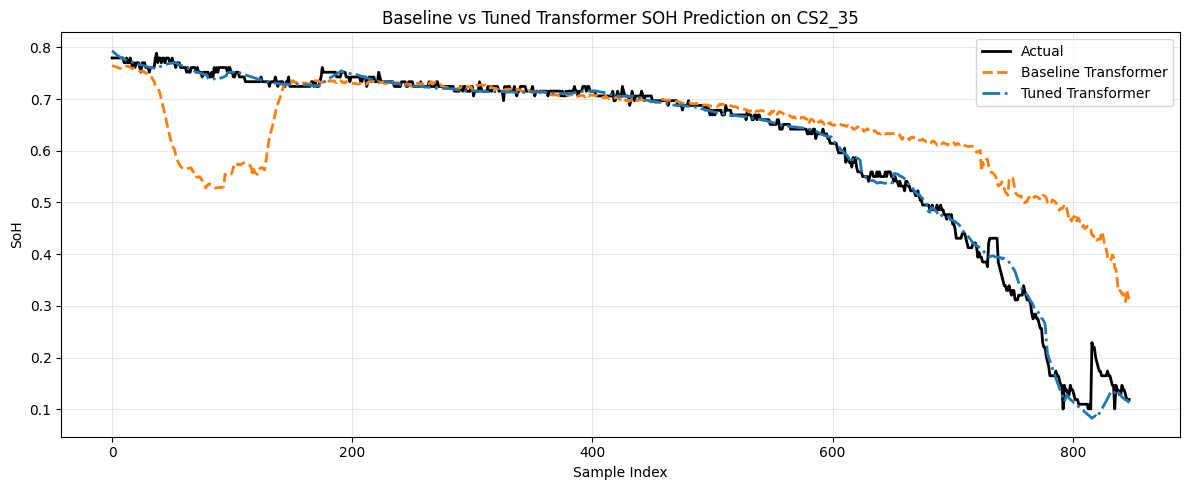

In [29]:
# Plot 1: Baseline vs Tuned Transformer on hold-out battery
required_vars = [
    'y_true_base',
    'y_pred_base',
    'y_test_true',
    'y_pred_test',
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        'Missing variables: ' + ', '.join(missing) + '. Run baseline and tuned Transformer cells first.'
    )

n_base = min(len(y_true_base), len(y_pred_base))
n_tuned = min(len(y_test_true), len(y_pred_test))
n_cmp = min(n_base, n_tuned)

x_axis = np.arange(n_cmp)
y_true_cmp = np.asarray(y_test_true[:n_cmp]).ravel()
y_base_cmp = np.asarray(y_pred_base[:n_cmp]).ravel()
y_tuned_cmp = np.asarray(y_pred_test[:n_cmp]).ravel()

plt.figure(figsize=(12, 5))
plt.plot(x_axis, y_true_cmp, label='Actual', color='black', linewidth=2)
plt.plot(x_axis, y_base_cmp, label='Baseline Transformer', linestyle='--', linewidth=2, color='tab:orange')
plt.plot(x_axis, y_tuned_cmp, label='Tuned Transformer', linestyle='-.', linewidth=2, color='tab:blue')
plt.title('Baseline vs Tuned Transformer SOH Prediction on CS2_35')
plt.xlabel('Sample Index')
plt.ylabel('SoH')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Baseline vs Tuned Transformer (lower is better)
Metric  Baseline    Tuned  Improvement_%
  RMSE  0.079134 0.017073      78.424842
   MAE  0.032781 0.009483      71.070207


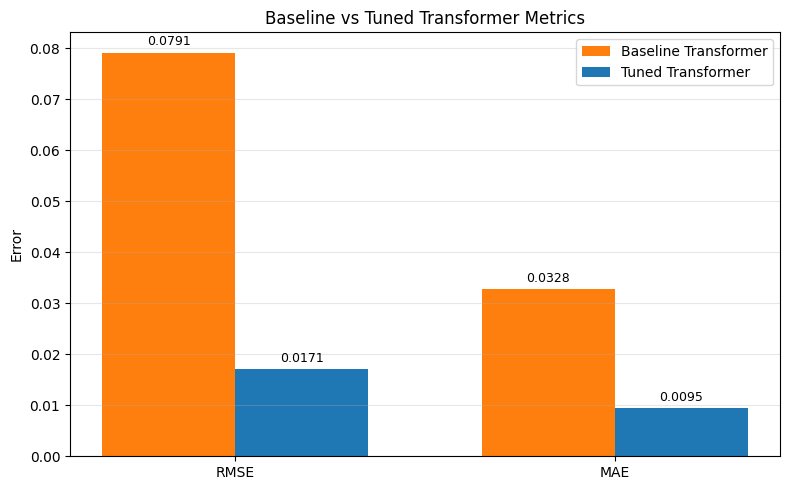


Saved: transformer_baseline_vs_tuned_comparison.csv


In [30]:
# Plot 2: Baseline vs Tuned Transformer metric comparison
required_vars = ['base_rmse', 'base_mae', 'rmse_imp_tuned', 'mae_imp_tuned']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        'Missing metrics: ' + ', '.join(missing) + '. Run baseline and tuned Transformer cells first.'
    )

comparison_transformer = pd.DataFrame([
    {'Model': 'Baseline Transformer', 'RMSE': float(base_rmse), 'MAE': float(base_mae)},
    {'Model': 'Tuned Transformer', 'RMSE': float(rmse_imp_tuned), 'MAE': float(mae_imp_tuned)},
])

baseline_rmse = comparison_transformer.loc[
    comparison_transformer['Model'] == 'Baseline Transformer', 'RMSE'
].iloc[0]
baseline_mae = comparison_transformer.loc[
    comparison_transformer['Model'] == 'Baseline Transformer', 'MAE'
].iloc[0]
tuned_rmse = comparison_transformer.loc[
    comparison_transformer['Model'] == 'Tuned Transformer', 'RMSE'
].iloc[0]
tuned_mae = comparison_transformer.loc[
    comparison_transformer['Model'] == 'Tuned Transformer', 'MAE'
].iloc[0]

rmse_improvement_pct = (baseline_rmse - tuned_rmse) / baseline_rmse * 100.0 if baseline_rmse != 0 else np.nan
mae_improvement_pct = (baseline_mae - tuned_mae) / baseline_mae * 100.0 if baseline_mae != 0 else np.nan

summary = pd.DataFrame([
    {
        'Metric': 'RMSE',
        'Baseline': baseline_rmse,
        'Tuned': tuned_rmse,
        'Improvement_%': rmse_improvement_pct,
    },
    {
        'Metric': 'MAE',
        'Baseline': baseline_mae,
        'Tuned': tuned_mae,
        'Improvement_%': mae_improvement_pct,
    }
])

print('Baseline vs Tuned Transformer (lower is better)')
print(summary.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['RMSE', 'MAE']
baseline_vals = [baseline_rmse, baseline_mae]
tuned_vals = [tuned_rmse, tuned_mae]
x = np.arange(len(metrics))
width = 0.35

bars_base = ax.bar(x - width / 2, baseline_vals, width, label='Baseline Transformer', color='tab:orange')
bars_tuned = ax.bar(x + width / 2, tuned_vals, width, label='Tuned Transformer', color='tab:blue')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Error')
ax.set_title('Baseline vs Tuned Transformer Metrics')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()

for bar in list(bars_base) + list(bars_tuned):
    height = bar.get_height()
    ax.annotate(
        f'{height:.4f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

summary.to_csv('transformer_baseline_vs_tuned_comparison.csv', index=False)
print('\nSaved: transformer_baseline_vs_tuned_comparison.csv')

In [31]:
# Save the learning-curve figure created earlier in the notebook
try:
    fig.savefig('transformer_learning_curve.png', dpi=300)
    print('Saved: transformer_learning_curve.png')
except NameError:
    print('Figure `fig` not found in the current kernel. Re-run the plotting cell first.')


Saved: transformer_learning_curve.png
